In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

### **Getting Started with Scikit-Learn: The Perceptron**

To introduce the `scikit-learn` library, we will build a perceptron model using the built-in **Iris dataset**.

#### **1. Load the Iris dataset from scikit-learn.**

For simplicity and easy 2D visualization, we will filter the 150 flower examples down to just two features:
* **X (Feature Matrix):** Petal length and petal width.
* **y (Target Vector):** The corresponding flower species class labels.

In [3]:
from sklearn.datasets import load_iris
import numpy as np

In [4]:
iris = load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


#### **2. Split the dataset into training and testing.**

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [6]:
print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


#### **3. Standardize the features.**

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

#### **4. Train a Perceptron model.**

In [8]:
from sklearn.linear_model import Perceptron
ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

#### **5. Make predictions.**

In [9]:
y_pred = ppn.predict(X_test_std)
print('Misclassified examples: %d' % (y_test != y_pred).sum())

Misclassified examples: 1


#### **6. Calculate the classification accuracy of the perceptron.**

In [10]:
from sklearn.metrics import accuracy_score
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))

Accuracy: 0.978


In [11]:
print('Accuracy: %3f' %ppn.score(X_test_std, y_test))

Accuracy: 0.977778


#### **7. Decision boundaries.**

The perceptron algorithm never converges on datasets that aren’t perfectly linearly separable, which is why the use of the perceptron algorithm is typically not recommended in practice.


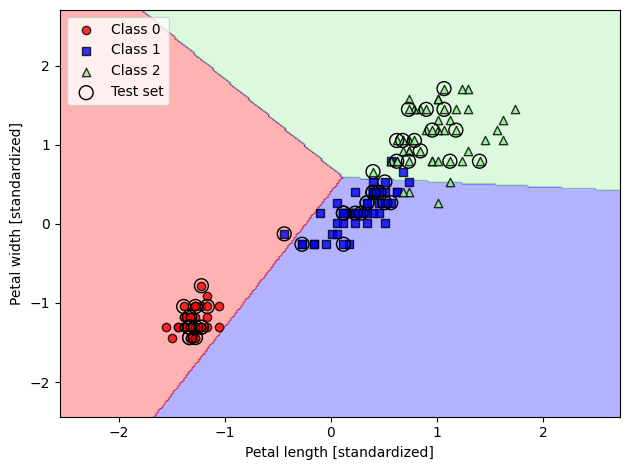

In [12]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=ppn,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()